
# Nevermore pipeline launcher

Run the cached Nevermore pipeline from a single notebook cell. Edit the config path or `up_to` stage as needed.


In [ ]:
import sys
from pathlib import Path
repo_root = Path.cwd()
if '__file__' in globals():
    repo_root = Path(__file__).resolve().parents[2]
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


from nevermore.pipeline import NevermorePipeline, STAGE_ORDER

config_path = "nevermore/configs/default.yaml"  # change if you keep overrides elsewhere
up_to = "retrieval"  # choose from: ingest, features, optimization, retrieval, visualization, docking, admet, report

pipe = NevermorePipeline(config_path=config_path)
results = pipe.run(up_to=up_to)

for name, res in results.items():
    print(f"[{name}] {res.signature} -> {res.outputs}")


In [ ]:

# Inspect candidates (if retrieval ran)
import pandas as pd
from pathlib import Path
retrieval = results.get("retrieval")
if retrieval and retrieval.outputs:
    cand_path = Path(retrieval.outputs.get("candidates", ""))
    if cand_path.exists():
        display(pd.read_csv(cand_path).head())


In [25]:
import json
import pandas as pd
import matplotlib.pyplot as plt

trace_path = "../../outputs/optimization/4f89466595e0/optimization_trace.csv"  # update signature
df = pd.read_csv(trace_path)

# Expand ADMET dict column into separate columns
def expand_admet(row):
    if pd.isna(row):
        return {}
    try:
        return json.loads(row)
    except Exception:
        return {}
admet_df = df["admet"].apply(expand_admet).apply(pd.Series)
df = pd.concat([df.drop(columns=["admet"]), admet_df], axis=1)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()

df.plot(x="iter", y="predicted_affinity", ax=axes[0], title="Predicted Affinity")
df.plot(x="iter", y="loss", ax=axes[1], title="Total Loss")
if "hERG" in df: df.plot(x="iter", y="hERG", ax=axes[2], title="hERG")
if "QED" in df: df.plot(x="iter", y="QED", ax=axes[3], title="QED")

plt.tight_layout()
plt.show()

# Show first/last rows for quick comparison
display(df.head(3))
display(df.tail(3))


KeyError: 'admet'

In [26]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRACE_PATH = "/scratch/home/sr3622/Firm-DTI/Firm-DTI2/outputs/optimization/4f89466595e0/optimization_trace_topk_stats.csv"

df = pd.read_csv(TRACE_PATH)
print("Rows:", len(df))
print("Columns:", list(df.columns))
display(df.head(5))


Rows: 163
Columns: ['iter', 'K', 'nn_k', 'loss_best', 'loss_avg_topk', 'loss_soft_topk', 'pred_best', 'pred_avg_topk', 'rep_penalty', 'ng_objective', 'projected_idx_best', 'topk_projected_idxs', 'topk_preds', 'topk_losses', 'topk_admet_penalties', 'topk_manifold_distances']


,iter,K,nn_k,loss_best,loss_avg_topk,loss_soft_topk,pred_best,pred_avg_topk,rep_penalty,ng_objective,projected_idx_best,topk_projected_idxs,topk_preds,topk_losses,topk_admet_penalties,topk_manifold_distances
0,0,30,30,111.618025,152.035965,111.618027,5.528174,3.762040,0.0,111.618027,12998,"[169940, 169702, 38064, 169729, 169752, 169833...","[3.5918262004852295, 3.5918262004852295, 4.065...","[156.162774873719, 156.162774873719, 144.62232...","[2.199997834754196, 2.199997834754196, 2.18264...","[10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10...."
1,1,30,30,111.618025,151.791000,111.618027,5.528174,3.772262,0.0,111.618027,12998,"[169808, 169833, 38064, 169917, 169896, 169752...","[3.5918262004852295, 3.5918262004852295, 4.065...","[156.162774873719, 156.162774873719, 144.62232...","[2.199997834754196, 2.199997834754196, 2.18264...","[15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15...."
2,2,30,30,66.988868,147.359955,66.996132,7.829634,4.004437,0.0,66.996132,21230,"[26727, 169940, 21227, 169917, 169896, 38064, ...","[3.9862945079803467, 3.5918262004852295, 7.597...","[146.48278274152443, 156.162774873719, 71.8718...","[2.1536630925412483, 2.199997834754196, 1.2747...","[15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15...."
3,3,30,30,57.099983,140.013657,57.178360,8.587379,4.383026,0.0,57.178360,69112,"[169808, 21227, 69136, 169896, 69112, 169940, ...","[3.5918262004852295, 7.597795486450195, 8.5773...","[156.162774873719, 71.87183939745235, 57.27067...","[2.199997834754196, 1.27479870993564, 2.174203...","[20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20...."
4,4,30,30,57.099983,145.170914,57.178360,8.587379,4.133933,0.0,57.178360,69112,"[69274, 169854, 169940, 169729, 169833, 169752...","[8.56972599029541, 3.5918262004852295, 3.59182...","[57.18376908150623, 156.162774873719, 156.1627...","[1.974797222214705, 2.199997834754196, 2.19999...","[15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15...."


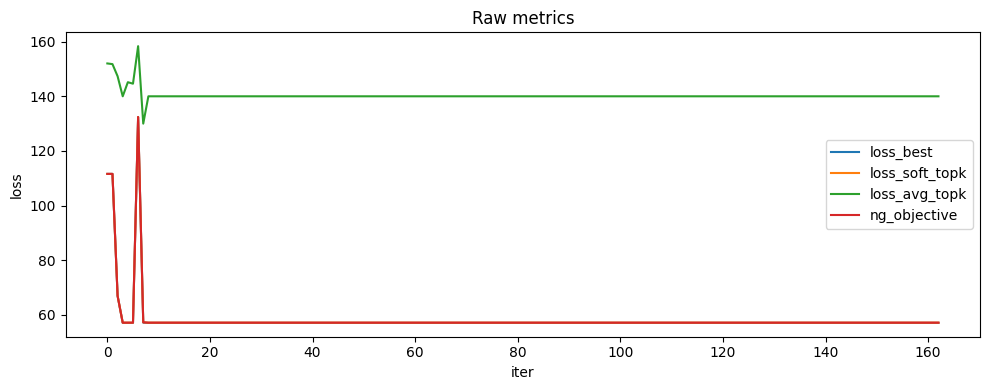

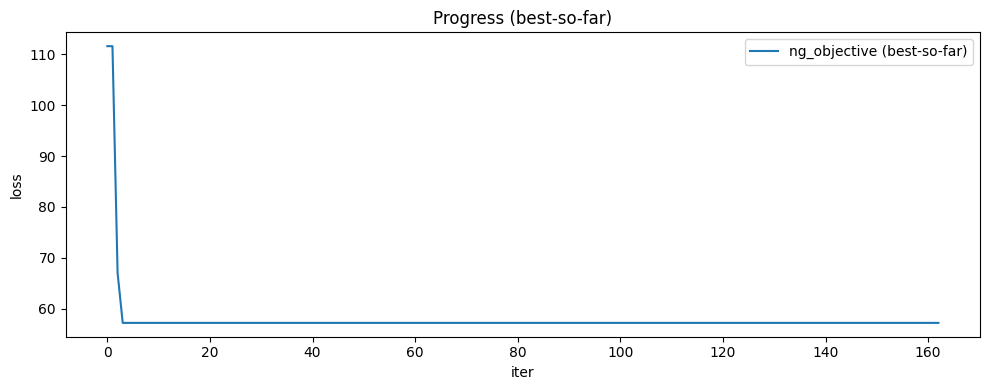

In [27]:
import matplotlib.pyplot as plt

# pick columns that exist
cols = [c for c in ["loss_best", "loss_soft_topk", "loss_avg_topk", "ng_objective"] if c in df.columns]
# cols = [c for c in ["loss_soft_topk"] if c in df.columns]

# plot raw
plt.figure(figsize=(10,4))
for c in cols:
    plt.plot(df["iter"], df[c], label=c)
plt.legend(); plt.xlabel("iter"); plt.ylabel("loss"); plt.title("Raw metrics"); plt.tight_layout(); plt.show()

# plot best-so-far for ng_objective
if "ng_objective" in df.columns:
    df["ng_best_so_far"] = df["ng_objective"].cummin()
    plt.figure(figsize=(10,4))
    plt.plot(df["iter"], df["ng_best_so_far"], label="ng_objective (best-so-far)")
    plt.legend(); plt.xlabel("iter"); plt.ylabel("loss"); plt.title("Progress (best-so-far)"); plt.tight_layout(); plt.show()


Rows: 163
Columns: ['iter', 'K', 'nn_k', 'loss_best', 'loss_avg_topk', 'loss_soft_topk', 'pred_best', 'pred_avg_topk', 'rep_penalty', 'ng_objective', 'projected_idx_best', 'topk_projected_idxs', 'topk_preds', 'topk_losses', 'topk_admet_penalties', 'topk_manifold_distances', 'ng_best_so_far']


,iter,K,nn_k,loss_best,loss_avg_topk,loss_soft_topk,pred_best,pred_avg_topk,rep_penalty,ng_objective,projected_idx_best,topk_projected_idxs,topk_preds,topk_losses,topk_admet_penalties,topk_manifold_distances,ng_best_so_far
0,0,30,30,111.618025,152.035965,111.618027,5.528174,3.762040,0.0,111.618027,12998,"[169940, 169702, 38064, 169729, 169752, 169833...","[3.5918262004852295, 3.5918262004852295, 4.065...","[156.162774873719, 156.162774873719, 144.62232...","[2.199997834754196, 2.199997834754196, 2.18264...","[10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10....",111.618027
1,1,30,30,111.618025,151.791000,111.618027,5.528174,3.772262,0.0,111.618027,12998,"[169808, 169833, 38064, 169917, 169896, 169752...","[3.5918262004852295, 3.5918262004852295, 4.065...","[156.162774873719, 156.162774873719, 144.62232...","[2.199997834754196, 2.199997834754196, 2.18264...","[15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15....",111.618027
2,2,30,30,66.988868,147.359955,66.996132,7.829634,4.004437,0.0,66.996132,21230,"[26727, 169940, 21227, 169917, 169896, 38064, ...","[3.9862945079803467, 3.5918262004852295, 7.597...","[146.48278274152443, 156.162774873719, 71.8718...","[2.1536630925412483, 2.199997834754196, 1.2747...","[15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15....",66.996132
3,3,30,30,57.099983,140.013657,57.178360,8.587379,4.383026,0.0,57.178360,69112,"[169808, 21227, 69136, 169896, 69112, 169940, ...","[3.5918262004852295, 7.597795486450195, 8.5773...","[156.162774873719, 71.87183939745235, 57.27067...","[2.199997834754196, 1.27479870993564, 2.174203...","[20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20....",57.178360
4,4,30,30,57.099983,145.170914,57.178360,8.587379,4.133933,0.0,57.178360,69112,"[69274, 169854, 169940, 169729, 169833, 169752...","[8.56972599029541, 3.5918262004852295, 3.59182...","[57.18376908150623, 156.162774873719, 156.1627...","[1.974797222214705, 2.199997834754196, 2.19999...","[15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15....",57.178360


Detected affinity columns: ['pred_best']


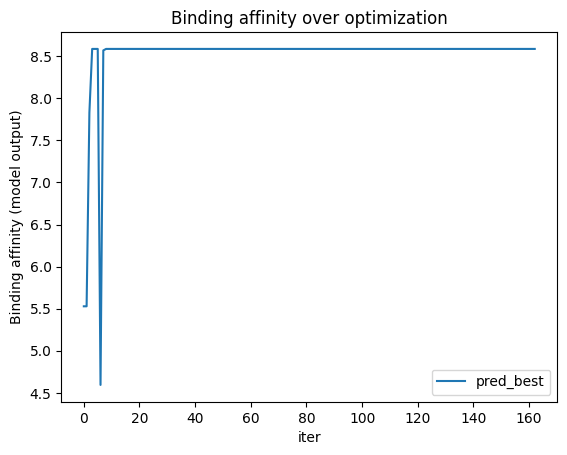


Top-10 highest 'pred_best' rows:


,pred_best,iter,row
162,8.587379,162,162
161,8.587379,161,161
146,8.587379,146,146
147,8.587379,147,147
148,8.587379,148,148
149,8.587379,149,149
150,8.587379,150,150
151,8.587379,151,151
152,8.587379,152,152
153,8.587379,153,153



Final row:


,iter,pred_best
162,162,8.587379


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


print("Rows:", len(df))
print("Columns:", list(df.columns))
display(df.head())

# ---- pick x-axis ----
xcol = "iter" if "iter" in df.columns else None
if xcol is None:
    # fallback: first numeric-ish column, else use index
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    xcol = numeric_cols[0] if numeric_cols else None

x = df[xcol] if xcol is not None else np.arange(len(df))

# ---- detect affinity columns ----
aff_cols = [c for c in df.columns if "affinity" in c.lower()]
# common extra names
for c in ["pred_best", "pred"]:
    if c in df.columns and c not in aff_cols:
        aff_cols.append(c)

# keep only numeric
aff_cols = [c for c in aff_cols if pd.api.types.is_numeric_dtype(df[c])]

print("Detected affinity columns:", aff_cols)

# ---- plot affinity over iterations ----
if not aff_cols:
    raise ValueError("No numeric affinity columns found. Check df.columns above and tell me which column is affinity.")

plt.figure()
for c in aff_cols:
    plt.plot(x, df[c], label=c)
plt.xlabel(xcol if xcol is not None else "step")
plt.ylabel("Binding affinity (model output)")
plt.title("Binding affinity over optimization")
plt.legend()
plt.show()

# ---- show top affinities (highest) ----
main_aff = "pred_avg_topk" if "pred_avg_topk" in aff_cols else aff_cols[0]

top = df[[main_aff] + ([xcol] if xcol in df.columns else [])].copy()
top["row"] = np.arange(len(df))

top10 = top.sort_values(main_aff, ascending=False).head(10)
print(f"\nTop-10 highest '{main_aff}' rows:")
display(top10)

print("\nFinal row:")
display(df.tail(1)[([xcol] if xcol in df.columns else []) + aff_cols])
